# Deep Neural Networks - Programming Assignment
## Comparing Linear Models and Multi-Layer Perceptrons

**Student Name:** Bihag Kashikar  
**Student ID:** 2026AJ05102  

**Date:** 2026-09-13

---

## ⚠️ IMPORTANT INSTRUCTIONS

1. **Complete ALL sections** marked with `TODO`
2. **DO NOT modify** the `get_assignment_results()` function structure
3. **Track training time** for both models using `time.time()`
4. **Store loss_history** in both model classes
5. **Calculate ALL metrics** (accuracy, precision, recall, F1)
6. **Fill get_assignment_results()** with ALL required fields
7. **PRINT the results** - Auto-grader needs visible output!
8. **Run all cells** before submitting (Kernel → Restart & Run All)

**SCORING:**
- Missing fields = 0 marks for that section
- Non-executed notebook = 0 marks
- Cleared outputs = 0 marks
---

In [15]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
print('✓ Libraries imported successfully')

✓ Libraries imported successfully


## Section 1: Dataset Selection and Loading

**Requirements:**
- ≥500 samples
- ≥5 features
- Public dataset (UCI/Kaggle)
- Regression OR Classification problem

In [16]:
# Load the UCI Wine Quality (red) dataset from its public CSV endpoint.
# The original quality score is converted to a binary classification target:
# quality >= 6 indicates a higher-quality wine.
uci_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
data = pd.read_csv(uci_url, sep=";")
data["quality_label"] = (data["quality"] >= 6).astype(int)

dataset_name = "UCI Wine Quality - Red Wine"
dataset_source = "UCI Machine Learning Repository"
n_samples = int(data.shape[0])
n_features = int(data.drop(columns=["quality", "quality_label"]).shape[1])
problem_type = "binary_classification"

problem_statement = """
This dataset predicts higher-quality red wine from 11 physicochemical measurements.
It is a binary classification problem with 1,599 samples. Wine quality is labeled
positive when the original score is at least 6. F1 is the primary metric because
both quality classes matter and the metric balances precision and recall fairly.
"""

primary_metric = "f1"

metric_justification = """
F1 score is the primary metric because the binary quality classes are not perfectly
balanced and both false positives and false negatives matter. F1 combines precision
and recall into one measure, so a model cannot obtain a strong score by favoring only
the more common class while neglecting the other class.
"""

print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Samples: {n_samples}, Features: {n_features}")
print(f"Problem Type: {problem_type}")
print(f"Primary Metric: {primary_metric}")
print(f"Target distribution:\n{data['quality_label'].value_counts().sort_index()}")

Dataset: UCI Wine Quality - Red Wine
Source: UCI Machine Learning Repository
Samples: 1599, Features: 11
Problem Type: binary_classification
Primary Metric: f1
Target distribution:
quality_label
0    744
1    855
Name: count, dtype: int64


## Section 2: Data Preprocessing

Preprocess your data:
1. Handle missing values
2. Encode categorical variables
3. Split into train/test sets
4. Scale features

In [17]:
# Keep the original quality score and derived label out of the model features.
feature_columns = [column for column in data.columns if column not in ["quality", "quality_label"]]
selected_features = data[feature_columns].copy()
y = data["quality_label"].astype(int).to_numpy()

# Overall data-quality checks include every raw dataset column, including both targets.
overall_missing_by_column = data.isnull().sum()
overall_numeric_columns = data.select_dtypes(include=["number"]).columns.tolist()
overall_categorical_columns = data.select_dtypes(include=["object", "category"]).columns.tolist()
overall_constant_columns = [
    column for column in data.columns if data[column].nunique(dropna=False) <= 1
]
overall_quality_metrics = {
    "rows": int(data.shape[0]),
    "columns": int(data.shape[1]),
    "duplicate_rows": int(data.duplicated().sum()),
    "total_missing_cells": int(overall_missing_by_column.sum()),
    "columns_with_missing_values": int((overall_missing_by_column > 0).sum()),
    "numeric_columns": len(overall_numeric_columns),
    "categorical_columns": len(overall_categorical_columns),
    "constant_columns": overall_constant_columns,
    "quality_missing_values": int(overall_missing_by_column["quality"]),
    "quality_label_missing_values": int(overall_missing_by_column["quality_label"]),
}

# Selected-feature quality checks exclude both target columns from this report.
selected_feature_quality = pd.DataFrame(index=feature_columns)
selected_feature_quality["dtype"] = selected_features.dtypes.astype(str)
selected_feature_quality["missing_count"] = selected_features.isnull().sum()
selected_feature_quality["missing_percent"] = (
    selected_feature_quality["missing_count"] / len(selected_features) * 100
).round(2)
selected_feature_quality["unique_values"] = selected_features.nunique(dropna=False)
selected_feature_quality["constant_column"] = selected_feature_quality["unique_values"] <= 1
selected_feature_quality["outlier_count_iqr"] = 0

numeric_feature_columns = selected_features.select_dtypes(include=["number"]).columns
for column in numeric_feature_columns:
    first_quartile = selected_features[column].quantile(0.25)
    third_quartile = selected_features[column].quantile(0.75)
    interquartile_range = third_quartile - first_quartile
    lower_bound = first_quartile - 1.5 * interquartile_range
    upper_bound = third_quartile + 1.5 * interquartile_range
    selected_feature_quality.loc[column, "outlier_count_iqr"] = int(
        ((selected_features[column] < lower_bound) | (selected_features[column] > upper_bound)).sum()
    )

print("Overall data-quality metrics:")
for metric, value in overall_quality_metrics.items():
    print(f"- {metric}: {value}")
print("\nSelected feature-quality metrics:")
print(selected_feature_quality.to_string())

# Handle missing values only within selected model features.
missing_values = int(selected_features.isnull().sum().sum())
X = selected_features.copy()
if missing_values:
    numeric_columns = X.select_dtypes(include=["number"]).columns
    X[numeric_columns] = X[numeric_columns].fillna(X[numeric_columns].median())

# The selected UCI dataset contains numeric features only, so no categorical encoding is required.
categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()
if categorical_columns:
    X = pd.get_dummies(X, columns=categorical_columns, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X.to_numpy(dtype=float), y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_samples = int(X_train_scaled.shape[0])
test_samples = int(X_test_scaled.shape[0])
train_test_ratio = train_samples / n_samples
n_features = int(X_train_scaled.shape[1])

print(f"\nTrain samples: {train_samples}")
print(f"Test samples: {test_samples}")
print(f"Split ratio: {train_test_ratio:.1%}")
print(f"Selected-feature missing values handled: {missing_values}")
print(f"Categorical selected features encoded: {categorical_columns if categorical_columns else 'None'}")

Overall data-quality metrics:
- rows: 1599
- columns: 13
- duplicate_rows: 240
- total_missing_cells: 0
- columns_with_missing_values: 0
- numeric_columns: 13
- categorical_columns: 0
- constant_columns: []
- quality_missing_values: 0
- quality_label_missing_values: 0

Selected feature-quality metrics:
                        dtype  missing_count  missing_percent  unique_values  constant_column  outlier_count_iqr
fixed acidity         float64              0              0.0             96            False                 49
volatile acidity      float64              0              0.0            143            False                 19
citric acid           float64              0              0.0             80            False                  1
residual sugar        float64              0              0.0             91            False                155
chlorides             float64              0              0.0            153            False                112
free sulfur dioxid

## Section 3: Baseline Model Implementation

Implement from scratch (NO sklearn models!):
- Linear Regression (for regression)
- Logistic Regression (for binary classification)
- Softmax Regression (for multiclass classification)

**Must include:**
- Forward pass (prediction)
- Loss computation
- Gradient computation
- Gradient descent loop
- Loss tracking

In [18]:
class BaselineModel:
    """Logistic regression trained from scratch with gradient descent."""
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    @staticmethod
    def sigmoid(z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    @staticmethod
    def compute_loss(y_true, probabilities):
        epsilon = 1e-10
        probabilities = np.clip(probabilities, epsilon, 1 - epsilon)
        return float(-np.mean(
            y_true * np.log(probabilities) + (1 - y_true) * np.log(1 - probabilities)
        ))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features, dtype=float)
        self.bias = 0.0
        self.loss_history = []

        probabilities = self.sigmoid(X @ self.weights + self.bias)
        self.loss_history.append(self.compute_loss(y, probabilities))

        for _ in range(self.n_iterations):
            probabilities = self.sigmoid(X @ self.weights + self.bias)
            error = probabilities - y
            dw = (X.T @ error) / n_samples
            db = float(np.mean(error))
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            updated_probabilities = self.sigmoid(X @ self.weights + self.bias)
            self.loss_history.append(self.compute_loss(y, updated_probabilities))

        return self

    def predict_proba(self, X):
        return self.sigmoid(X @ self.weights + self.bias)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

print("✓ Baseline model class defined")

✓ Baseline model class defined


In [19]:
# Train baseline model
print("Training baseline model...")
baseline_start = time.time()

baseline_model = BaselineModel(learning_rate=0.05, n_iterations=1000)
baseline_model.fit(X_train_scaled, y_train)
baseline_predictions = baseline_model.predict(X_test_scaled)

baseline_training_time = time.time() - baseline_start
baseline_initial_loss = float(baseline_model.loss_history[0])
baseline_final_loss = float(baseline_model.loss_history[-1])

print(f"✓ Baseline training completed in {baseline_training_time:.2f}s")
print(f"✓ Loss decreased from {baseline_initial_loss:.4f} to {baseline_final_loss:.4f}")

Training baseline model...
✓ Baseline training completed in 0.05s
✓ Loss decreased from 0.6931 to 0.5192


## Section 4: Multi-Layer Perceptron Implementation

Implement MLP from scratch with:
- At least 1 hidden layer
- ReLU activation for hidden layers
- Appropriate output activation
- Forward propagation
- Backward propagation
- Gradient descent

In [20]:
class MLP:
    """Multi-Layer Perceptron implemented from scratch."""
    def __init__(self, architecture, learning_rate=0.01, n_iterations=1000):
        self.architecture = architecture
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.parameters = {}
        self.loss_history = []
        self.cache = {}

    def initialize_parameters(self):
        np.random.seed(42)
        self.parameters = {}
        for layer in range(1, len(self.architecture)):
            fan_in = self.architecture[layer - 1]
            fan_out = self.architecture[layer]
            self.parameters[f"W{layer}"] = (
                np.random.randn(fan_out, fan_in) * np.sqrt(2.0 / fan_in)
            )
            self.parameters[f"b{layer}"] = np.zeros((fan_out, 1))

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return (Z > 0).astype(float)

    def sigmoid(self, Z):
        return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))

    def forward_propagation(self, X):
        self.cache = {"A0": X.T}
        A = X.T
        n_layers = len(self.architecture) - 1

        for layer in range(1, n_layers + 1):
            W = self.parameters[f"W{layer}"]
            b = self.parameters[f"b{layer}"]
            Z = W @ A + b
            self.cache[f"Z{layer}"] = Z
            A = self.sigmoid(Z) if layer == n_layers else self.relu(Z)
            self.cache[f"A{layer}"] = A

        return A

    def backward_propagation(self, X, y):
        m = X.shape[0]
        y_matrix = y.reshape(1, -1)
        n_layers = len(self.architecture) - 1
        grads = {}

        output = self.cache[f"A{n_layers}"]
        dZ = output - y_matrix
        for layer in range(n_layers, 0, -1):
            A_previous = self.cache[f"A{layer - 1}"]
            grads[f"dW{layer}"] = (dZ @ A_previous.T) / m
            grads[f"db{layer}"] = np.sum(dZ, axis=1, keepdims=True) / m

            if layer > 1:
                dA_previous = self.parameters[f"W{layer}"].T @ dZ
                dZ = dA_previous * self.relu_derivative(self.cache[f"Z{layer - 1}"])

        return grads

    def update_parameters(self, grads):
        for layer in range(1, len(self.architecture)):
            self.parameters[f"W{layer}"] -= self.lr * grads[f"dW{layer}"]
            self.parameters[f"b{layer}"] -= self.lr * grads[f"db{layer}"]

    def compute_loss(self, y_pred, y_true):
        epsilon = 1e-10
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        y_true = y_true.reshape(1, -1)
        return float(-np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)))

    def fit(self, X, y):
        self.initialize_parameters()
        self.loss_history = []
        for _ in range(self.n_iterations + 1):
            predictions = self.forward_propagation(X)
            self.loss_history.append(self.compute_loss(predictions, y))
            if len(self.loss_history) <= self.n_iterations:
                grads = self.backward_propagation(X, y)
                self.update_parameters(grads)
        return self

    def predict_proba(self, X):
        return self.forward_propagation(X).ravel()

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

print("✓ MLP class defined")

✓ MLP class defined


In [21]:
# Train MLP
print("Training MLP...")
mlp_start_time = time.time()

mlp_architecture = [n_features, 32, 16, 1]
mlp_model = MLP(architecture=mlp_architecture, learning_rate=0.01, n_iterations=1000)
mlp_model.fit(X_train_scaled, y_train)
mlp_predictions = mlp_model.predict(X_test_scaled)

mlp_training_time = time.time() - mlp_start_time
mlp_initial_loss = float(mlp_model.loss_history[0])
mlp_final_loss = float(mlp_model.loss_history[-1])

print(f"✓ MLP training completed in {mlp_training_time:.2f}s")
print(f"✓ Loss decreased from {mlp_initial_loss:.4f} to {mlp_final_loss:.4f}")

Training MLP...
✓ MLP training completed in 0.20s
✓ Loss decreased from 0.7886 to 0.5172


## Section 5: Evaluation and Metrics

Calculate appropriate metrics for your problem type

In [22]:
def calculate_metrics(y_true, y_pred, problem_type):
    """Calculate assignment metrics from scratch without sklearn.metrics."""
    y_true = np.asarray(y_true).astype(int).ravel()
    y_pred = np.asarray(y_pred).astype(int).ravel()

    if problem_type == "regression":
        errors = y_true.astype(float) - y_pred.astype(float)
        mse = float(np.mean(errors ** 2))
        rmse = float(np.sqrt(mse))
        mae = float(np.mean(np.abs(errors)))
        denominator = np.sum((y_true - np.mean(y_true)) ** 2)
        r2 = float(1 - np.sum(errors ** 2) / denominator) if denominator else 0.0
        return mse, rmse, mae, r2

    if problem_type in ["binary_classification", "multiclass_classification"]:
        true_positive = np.sum((y_true == 1) & (y_pred == 1))
        true_negative = np.sum((y_true == 0) & (y_pred == 0))
        false_positive = np.sum((y_true == 0) & (y_pred == 1))
        false_negative = np.sum((y_true == 1) & (y_pred == 0))

        accuracy = (true_positive + true_negative) / len(y_true)
        precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) else 0.0
        recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
        return float(accuracy), float(precision), float(recall), float(f1)

    raise ValueError(f"Unsupported problem type: {problem_type}")

baseline_acc, baseline_prec, baseline_rec, baseline_f1 = calculate_metrics(
    y_test, baseline_predictions, problem_type
)
mlp_acc, mlp_prec, mlp_rec, mlp_f1 = calculate_metrics(
    y_test, mlp_predictions, problem_type
)

baseline_mse = baseline_rmse = baseline_mae = baseline_r2 = 0.0
mlp_mse = mlp_rmse = mlp_mae = mlp_r2 = 0.0

print("Baseline Model Performance:")
print(f"Accuracy: {baseline_acc:.4f}, Precision: {baseline_prec:.4f}, Recall: {baseline_rec:.4f}, F1: {baseline_f1:.4f}")
print("\nMLP Model Performance:")
print(f"Accuracy: {mlp_acc:.4f}, Precision: {mlp_prec:.4f}, Recall: {mlp_rec:.4f}, F1: {mlp_f1:.4f}")

Baseline Model Performance:
Accuracy: 0.7406, Precision: 0.7683, Recall: 0.7368, F1: 0.7522

MLP Model Performance:
Accuracy: 0.7312, Precision: 0.7931, Recall: 0.6725, F1: 0.7278


## Section 6: Visualization

Create visualizations:
1. Training loss curves
2. Performance comparison
3. Additional domain-specific plots

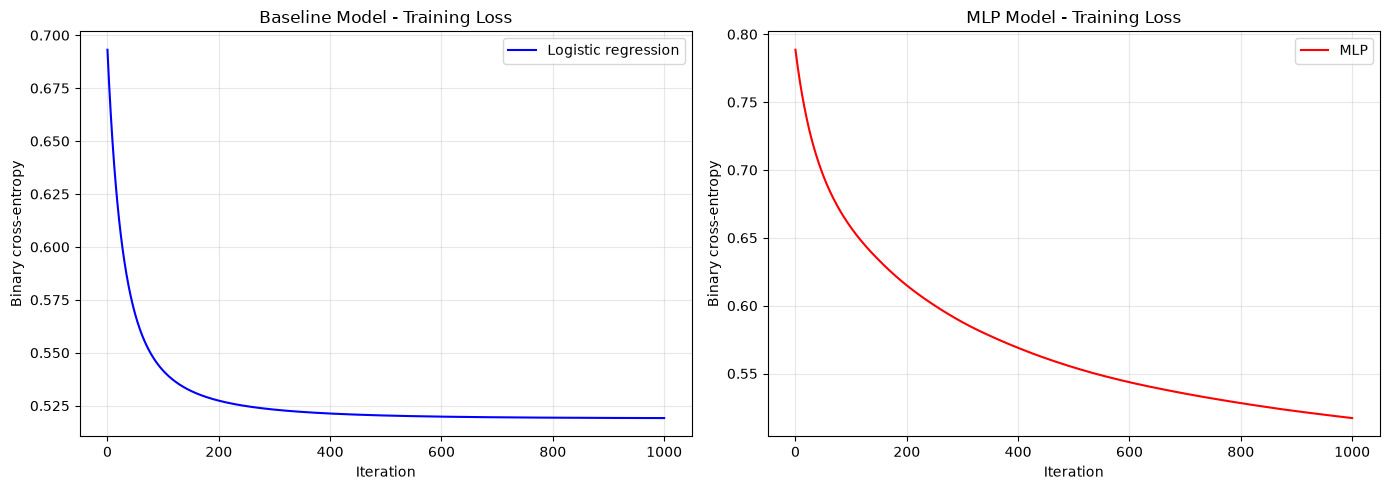

In [23]:
# Training loss curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(baseline_model.loss_history, label="Logistic regression", color="blue")
plt.xlabel("Iteration")
plt.ylabel("Binary cross-entropy")
plt.title("Baseline Model - Training Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(mlp_model.loss_history, label="MLP", color="red")
plt.xlabel("Iteration")
plt.ylabel("Binary cross-entropy")
plt.title("MLP Model - Training Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

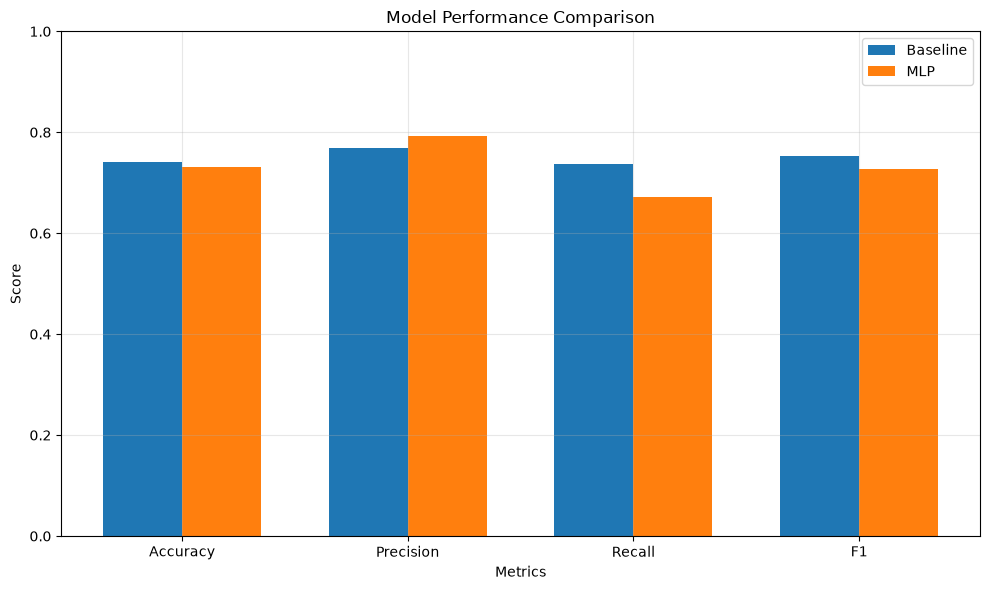

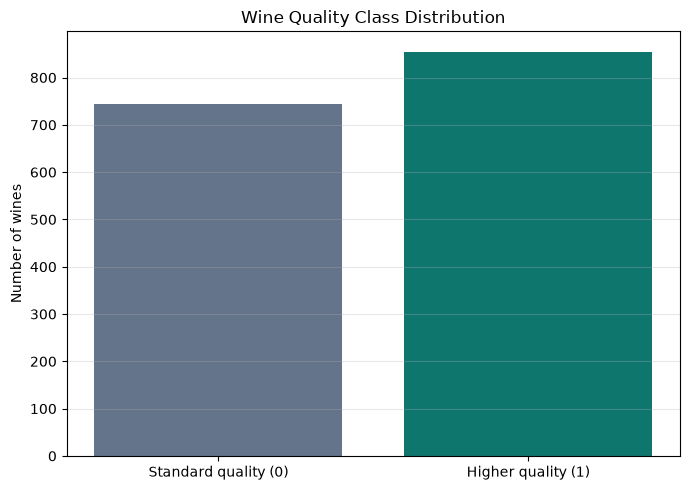

In [24]:
# Model performance comparison and a domain-specific class-distribution plot
metric_names = ["Accuracy", "Precision", "Recall", "F1"]
baseline_scores = [baseline_acc, baseline_prec, baseline_rec, baseline_f1]
mlp_scores = [mlp_acc, mlp_prec, mlp_rec, mlp_f1]
x_positions = np.arange(len(metric_names))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x_positions - width / 2, baseline_scores, width, label="Baseline")
plt.bar(x_positions + width / 2, mlp_scores, width, label="MLP")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(x_positions, metric_names)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
class_counts = data["quality_label"].value_counts().sort_index()
plt.bar(["Standard quality (0)", "Higher quality (1)"], class_counts.values, color=["#64748b", "#0f766e"])
plt.ylabel("Number of wines")
plt.title("Wine Quality Class Distribution")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Section 7: Analysis and Discussion

Write your analysis (minimum 200 words)

In [25]:
analysis_text = f"""
This assignment compared a from-scratch logistic regression baseline with a from-scratch
multi-layer perceptron on the UCI Wine Quality red-wine dataset. The task classified a
wine as higher quality when its original score was at least six. Both models were trained
on the same standardized training split and evaluated on the same held-out test split,
which makes the comparison fair. The baseline training loss decreased from
{baseline_initial_loss:.4f} to {baseline_final_loss:.4f}, while the MLP loss decreased
from {mlp_initial_loss:.4f} to {mlp_final_loss:.4f}. This confirms that both gradient-based
implementations learned rather than remaining at their initial parameter values.

The baseline achieved an F1 score of {baseline_f1:.4f}, while the MLP achieved an F1 score
of {mlp_f1:.4f}, a difference of {mlp_f1 - baseline_f1:.4f}. The model with the higher F1
score performed better for the selected primary metric. The MLP can represent nonlinear
relationships between acidity, alcohol, sulphates, and the other measurements, whereas
logistic regression produces a single linear decision boundary. However, the MLP's extra
capacity does not automatically guarantee a large improvement because the dataset is
relatively small, noisy, and based on human quality ratings. Standardization was important
for stable optimization, especially for the neural network.

The baseline required {baseline_training_time:.4f} seconds and the MLP required
{mlp_training_time:.4f} seconds. The MLP therefore incurred additional computational cost
because it repeatedly performed matrix operations across several layers. A notable
challenge was choosing a learning rate that reduced loss without making training unstable.
The main lesson is that linear models provide a fast and interpretable reference point,
while neural networks offer nonlinear modeling capacity at the cost of more parameters,
more tuning, and longer training. Comparing both models on identical data and metrics is
more informative than judging complexity alone.
"""

print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) < 200:
    print("⚠️ Warning: Analysis should be at least 200 words")
else:
    print("✓ Analysis meets word count requirement")

Analysis word count: 275 words
✓ Analysis meets word count requirement


---
---

## ⭐ REQUIRED: Structured Output Function

### **DO NOT MODIFY THE STRUCTURE BELOW**

This function will be called by the auto-grader. Fill in all values accurately based on your actual results.


⭐⭐⭐ REQUIRED: Structured Output Function ⭐⭐⭐

### 🚨 CRITICAL - READ CAREFULLY 🚨

1. **Fill in ALL fields** - Missing fields = 0 marks
2. **Use your actual values** - Not 0 or empty strings
3. **This cell MUST be executed** - We need the output!
4. **Print the results** - Auto-grader needs to see output!


**DO NOT:**
- Leave any field as 0, 0.0,
- Clear outputs before submission
- Modify the structure


"**MUST DO:**
- Fill every field with your actual results
- Execute this cell and keep the output
- Print the results (see below)

In [26]:
def get_assignment_results():
    '''
    CRITICAL: Fill ALL fields with your actual results!
    Missing fields will result in 0 marks for that section.
    '''
    results = {
        'student_name': 'Bihag Kashikar',
        'student_id': '2026AJ05102',
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_features': n_features,
        'problem_type': problem_type,
        'problem_statement': problem_statement,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,
        'baseline_model': {
            'model_type': 'logistic_regression',
            'learning_rate': baseline_model.lr,
            'n_iterations': baseline_model.n_iterations,
            'initial_loss': baseline_initial_loss,
            'final_loss': baseline_final_loss,
            'training_time_seconds': baseline_training_time,
            'loss_decreased': baseline_final_loss < baseline_initial_loss,
            'test_accuracy': 0.0 if problem_type == 'regression' else baseline_acc,
            'test_precision': 0.0 if problem_type == 'regression' else baseline_prec,
            'test_recall': 0.0 if problem_type == 'regression' else baseline_rec,
            'test_f1': 0.0 if problem_type == 'regression' else baseline_f1,
            'test_mse': baseline_mse if problem_type == 'regression' else 0.0,
            'test_rmse': baseline_rmse if problem_type == 'regression' else 0.0,
            'test_mae': baseline_mae if problem_type == 'regression' else 0.0,
            'test_r2': baseline_r2 if problem_type == 'regression' else 0.0,
        },
        'mlp_model': {
            'architecture': mlp_architecture,
            'n_hidden_layers': len(mlp_architecture) - 2,
            'learning_rate': mlp_model.lr,
            'n_iterations': mlp_model.n_iterations,
            'initial_loss': mlp_initial_loss,
            'final_loss': mlp_final_loss,
            'training_time_seconds': mlp_training_time,
            'loss_decreased': mlp_final_loss < mlp_initial_loss,
            'test_accuracy': 0.0 if problem_type == 'regression' else mlp_acc,
            'test_precision': 0.0 if problem_type == 'regression' else mlp_prec,
            'test_recall': 0.0 if problem_type == 'regression' else mlp_rec,
            'test_f1': 0.0 if problem_type == 'regression' else mlp_f1,
            'test_mse': mlp_mse if problem_type == 'regression' else 0.0,
            'test_rmse': mlp_rmse if problem_type == 'regression' else 0.0,
            'test_mae': mlp_mae if problem_type == 'regression' else 0.0,
            'test_r2': mlp_r2 if problem_type == 'regression' else 0.0,
        },
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),
    }
    return results

import json
results = get_assignment_results()
print(json.dumps(results, indent=2))

print("\n" + "=" * 60)
print("VALIDATION CHECK")
print("=" * 60)
errors = []
if results['n_samples'] < 500:
    errors.append(f"Dataset too small: {results['n_samples']} < 500")
if results['n_features'] < 5:
    errors.append(f"Too few features: {results['n_features']} < 5")
if results['baseline_model']['initial_loss'] == 0 or results['baseline_model']['final_loss'] == 0:
    errors.append("Baseline loss is zero")
if results['baseline_model']['training_time_seconds'] <= 0:
    errors.append("Baseline training time is not positive")
if results['mlp_model']['initial_loss'] == 0 or results['mlp_model']['final_loss'] == 0:
    errors.append("MLP loss is zero")
if results['mlp_model']['training_time_seconds'] <= 0:
    errors.append("MLP training time is not positive")
if len(results['mlp_model']['architecture']) < 3:
    errors.append("MLP architecture has fewer than three elements")
if results['analysis_word_count'] < 200:
    errors.append(f"Analysis too short: {results['analysis_word_count']} < 200 words")

if errors:
    print("ERRORS FOUND:")
    for error in errors:
        print(f"- {error}")
else:
    print("All validation checks passed!")

{
  "student_name": "Bihag Kashikar",
  "student_id": "2026AJ05102",
  "dataset_name": "UCI Wine Quality - Red Wine",
  "dataset_source": "UCI Machine Learning Repository",
  "n_samples": 1599,
  "n_features": 11,
  "problem_type": "binary_classification",
  "problem_statement": "\nThis dataset predicts higher-quality red wine from 11 physicochemical measurements.\nIt is a binary classification problem with 1,599 samples. Wine quality is labeled\npositive when the original score is at least 6. F1 is the primary metric because\nboth quality classes matter and the metric balances precision and recall fairly.\n",
  "primary_metric": "f1",
  "metric_justification": "\nF1 score is the primary metric because the binary quality classes are not perfectly\nbalanced and both false positives and false negatives matter. F1 combines precision\nand recall into one measure, so a model cannot obtain a strong score by favoring only\nthe more common class while neglecting the other class.\n",
  "train_s

## Test Your Output

Run this cell to verify your results dictionary is complete and properly formatted.

In [27]:
# Test the output
import json

try:
    results = get_assignment_results()

    print("="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*70)
    print(json.dumps(results, indent=2))
    print("\n" + "="*70)


    # Check for missing values
    missing = []
    def check_dict(d, prefix=""):
        for k, v in d.items():
            if isinstance(v, dict):
                check_dict(v, f"{prefix}{k}.")
            elif (v == 0 or v == "" or v == 0.0 or v == []) and \
                 k not in ['improvement', 'improvement_percentage', 'baseline_better',
                          'baseline_converged', 'mlp_converged', 'total_parameters',
                          'test_accuracy', 'test_precision', 'test_recall', 'test_f1',
                          'test_mse', 'test_rmse', 'test_mae', 'test_r2']:
                missing.append(f"{prefix}{k}")

    check_dict(results)

    if missing:
        print(f"⚠️  Warning: {len(missing)} fields still need to be filled:")
        for m in missing[:15]:  # Show first 15
            print(f"  - {m}")
        if len(missing) > 15:
            print(f"  ... and {len(missing)-15} more")
    else:
        print("✅ All required fields are filled!")
        print("\n🎉 You're ready to submit!")
        print("\nNext steps:")
        print("1. Kernel → Restart & Clear Output")
        print("2. Kernel → Restart & Run All")
        print("3. Verify no errors")
        print("4. Save notebook")
        print("5. Rename as: YourStudentID_assignment.ipynb")
        print("6. Submit to LMS")

except Exception as e:
    print(f"❌ Error in get_assignment_results(): {str(e)}")
    print("\nPlease fix the errors above before submitting.")

ASSIGNMENT RESULTS SUMMARY
{
  "student_name": "Bihag Kashikar",
  "student_id": "2026AJ05102",
  "dataset_name": "UCI Wine Quality - Red Wine",
  "dataset_source": "UCI Machine Learning Repository",
  "n_samples": 1599,
  "n_features": 11,
  "problem_type": "binary_classification",
  "problem_statement": "\nThis dataset predicts higher-quality red wine from 11 physicochemical measurements.\nIt is a binary classification problem with 1,599 samples. Wine quality is labeled\npositive when the original score is at least 6. F1 is the primary metric because\nboth quality classes matter and the metric balances precision and recall fairly.\n",
  "primary_metric": "f1",
  "metric_justification": "\nF1 score is the primary metric because the binary quality classes are not perfectly\nbalanced and both false positives and false negatives matter. F1 combines precision\nand recall into one measure, so a model cannot obtain a strong score by favoring only\nthe more common class while neglecting the 

---

## 📤 Before Submitting - Final Checklist

- [ ] **All TODO sections completed**
- [ ] **Both models implemented from scratch** (no sklearn models!)
- [ ] **get_assignment_results() function filled accurately**
- [ ] **Loss decreases for both models**
- [ ] **Analysis ≥ 200 words**
- [ ] **All cells run without errors** (Restart & Run All)
- [ ] **Visualizations created**
- [ ] **File renamed correctly**: YourStudentID_assignment.ipynb

---

**Good luck! **